In [25]:
  import os
  os.environ["TOKENIZERS_PARALLELISM"] = "false"

# 03 - Bird Classifier with Fast.ai

---

## Learning Objectives

By the end of this notebook, you will be able to:

1. **Explain** what transfer learning is and why it works
2. **Use** Fast.ai's DataBlock API to prepare image data
3. **Fine-tune** a pre-trained model (ResNet) for custom classification
4. **Evaluate** model performance with confusion matrices and top losses
5. **Export** a trained model for deployment

---

## Prerequisites

- Completed notebooks 01 and 02 (neural network foundations)
- Basic understanding of CNNs (convolutions, pooling)
- Fast.ai library installed (`pip install fastai`)

---

## What We're Building

A classifier that distinguishes between 5 bird species:
- Eagle
- Owl
- Parrot
- Penguin
- Flamingo

We'll achieve **90%+ accuracy** in just a few minutes of training. How? Transfer learning.

---

# Part 1: Understanding Transfer Learning

## The Problem with Training from Scratch

Training a deep neural network from scratch requires:
- **Millions of images** (ImageNet has 1.2M)
- **Days of GPU time** (even on powerful hardware)
- **Careful hyperparameter tuning**

For our 500 bird images, training from scratch would:
- Massively overfit
- Learn nothing useful
- Take forever

## Transfer Learning: Standing on Giants' Shoulders

**Key insight:** The early layers of image classifiers learn *general* visual features:
- Layer 1: Edges, gradients
- Layer 2: Textures, patterns
- Layer 3: Parts (eyes, beaks, feathers)
- Layer 4+: Objects, scenes

These features are **universal** - useful for any image task!

```
┌─────────────────────────────────────────────────────────────────┐
│                    TRANSFER LEARNING                            │
├─────────────────────────────────────────────────────────────────┤
│                                                                  │
│   Pre-trained on ImageNet         Fine-tuned on Birds           │
│   (1.2M images, 1000 classes)     (500 images, 5 classes)       │
│                                                                  │
│   ┌─────────────────┐             ┌─────────────────┐           │
│   │ Edges, textures │ ─────────►  │ Edges, textures │ KEEP      │
│   ├─────────────────┤             ├─────────────────┤           │
│   │ Shapes, parts   │ ─────────►  │ Shapes, parts   │ KEEP      │
│   ├─────────────────┤             ├─────────────────┤           │
│   │ Objects         │ ─────────►  │ Bird features   │ FINE-TUNE │
│   ├─────────────────┤             ├─────────────────┤           │
│   │ 1000 classes    │             │ 5 bird classes  │ REPLACE   │
│   └─────────────────┘             └─────────────────┘           │
│                                                                  │
└─────────────────────────────────────────────────────────────────┘
```

## Why It Works

| Training Type | Data Needed | Time | Accuracy |
|---------------|-------------|------|----------|
| From scratch | 1M+ images | Days | Highest (if enough data) |
| Transfer learning | 100-1000 | Minutes | Very high |
| Few-shot learning | 5-10 | Seconds | Moderate |

**Transfer learning is the default approach for most real-world vision tasks.**

---

## 🧠 Conceptual Check

Before we start coding, think about these questions:

1. If ResNet was trained on ImageNet (which includes some bird species), why do we still need to fine-tune for our specific birds?

2. Which layers of the network should change more during fine-tuning: early layers (edges) or late layers (objects)?

3. If you wanted to classify X-ray images, would transfer learning from ImageNet still help? Why or why not?

4. Why might a model trained on 1 million images generalize better than one trained on 1000, even for simple tasks?

*Think about these, then continue to see the answers in practice.*

---

### 💬 LLM Discussion Prompts

Use these prompts with an LLM to deepen your understanding:

> "Explain transfer learning to me like I'm a chef learning to cook a new cuisine. What knowledge transfers and what needs to be relearned?"

> "If I train a model on photos and want to use it on cartoon images, will transfer learning work? What about medical X-rays?"

> "What's the difference between feature extraction (frozen backbone) and fine-tuning? When would I use each?"

---

# Part 2: Environment Setup

In [13]:
# Environment check
import sys
print(f"Python: {sys.version.split()[0]}")

# Check GPU
import torch
print(f"\nPyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU detected. Training will be slow.")

Python: 3.11.14

PyTorch: 2.9.1+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5090
VRAM: 33.7 GB


In [14]:
# Install dependencies if needed
!pip install -Uqq ddgs

# Core imports
from ddgs import DDGS
from fastcore.all import *
from fastdownload import download_url
from fastai.vision.all import *
from time import sleep

print("\n✅ All imports successful!")


✅ All imports successful!


---

# Part 3: Data Collection

## The Dataset Challenge

Unlike traditional ML where datasets are provided, deep learning often requires:
- Collecting your own data
- Cleaning and verifying images
- Handling corrupted or mislabeled data

We'll collect images using web search (via the `ddgs` library with Google backend), which teaches real-world data collection skills.

In [15]:
# Image search function using ddgs with Google backend
def search_images(keywords, max_images=100):
    """
    Search for images using Google backend.
    
    Args:
        keywords: Search term
        max_images: Maximum images to return
    
    Returns:
        List of image URLs
    """
    sleep(1)  # Small delay between searches
    results = DDGS().images(keywords, max_results=max_images, backend="google")
    return L(results).itemgot('image')

# Test the search
print("Testing image search...")
test_urls = search_images('eagle bird wildlife photography', max_images=3)
print(f"Found {len(test_urls)} images")
print(f"Sample URL: {test_urls[0][:80]}...")

Testing image search...
Found 3 images
Sample URL: http://www.runic.com/gallery/cache/wildlife/birds/golden-eagle-5_1200_copyright....


In [ ]:
# Define our bird classes and search queries
# More specific queries = more consistent, higher quality results

BIRD_CLASSES = ['eagle', 'owl', 'parrot', 'penguin', 'flamingo']

# Multiple queries per class for variety
SEARCH_QUERIES = {
    'eagle': [
        'bald eagle bird wildlife photography',
        'golden eagle flying photo',
        'eagle portrait close up'
    ],
    'owl': [
        'owl bird wildlife photography portrait',
        'snowy owl photo',
        'great horned owl close up'
    ],
    'parrot': [
        'colorful parrot bird tropical photography',
        'macaw parrot photo',
        'african grey parrot portrait'
    ],
    'penguin': [
        'emperor penguin wildlife photography',
        'penguin colony photo',
        'king penguin portrait'
    ],
    'flamingo': [
        'pink flamingo bird wildlife photography',
        'flamingo flock photo',
        'american flamingo portrait'
    ]
}

print("Bird classes:", BIRD_CLASSES)
print(f"Queries per class: {len(SEARCH_QUERIES['eagle'])}")

In [ ]:
# Create directory structure and download images
DATA_PATH = Path('bird_data')
DATA_PATH.mkdir(exist_ok=True)

IMAGES_PER_QUERY = 50  # Images to fetch per query

print("Downloading bird images...")
print("=" * 50)

for bird in BIRD_CLASSES:
    # Create class directory
    class_dir = DATA_PATH / bird
    class_dir.mkdir(exist_ok=True)
    
    # Download images for each query
    for query in SEARCH_QUERIES[bird]:
        print(f"Searching: {query}")
        try:
            urls = search_images(query, max_images=IMAGES_PER_QUERY)
            download_images(class_dir, urls=urls)
        except Exception as e:
            print(f"  Failed: {e}")
        sleep(1)  # Rate limiting

print("=" * 50)
print("Download complete!")

## Data Verification

Downloaded images often have problems:
- Corrupted files
- Wrong format
- Too small
- Completely wrong content

Fast.ai's `verify_images` catches corrupted files automatically.

In [16]:
# Verify and clean downloaded images
print("Verifying images...")

# Find all image files
all_images = get_image_files(DATA_PATH)
print(f"Total images found: {len(all_images)}")

# Identify corrupted images
failed = verify_images(all_images)
print(f"Corrupted images: {len(failed)}")

# Remove corrupted images
if len(failed) > 0:
    print("Removing corrupted images...")
    failed.map(Path.unlink)

# Count images per class
print("\nImages per class:")
for bird in BIRD_CLASSES:
    count = len(list((DATA_PATH/bird).glob('*')))
    bar = '█' * (count // 5)
    print(f"  {bird:10s}: {bar} {count}")

Verifying images...
Total images found: 640
Corrupted images: 0

Images per class:
  eagle     : ████████████████████████ 120
  owl       : ██████████████████████████ 132
  parrot    : ██████████████████████████ 132
  penguin   : █████████████████████████ 127
  flamingo  : ██████████████████████████ 132


In [ ]:
# Import our CLIP utilities
import sys
sys.path.insert(0, '../..')  # Add project root to path

# Force reload if already imported (useful during development)
import importlib
if 'utils' in sys.modules:
    import utils
    importlib.reload(utils)
    if 'utils.image_utils' in sys.modules:
        importlib.reload(sys.modules['utils.image_utils'])

from utils import clean_image_folder, score_images_batch

In [18]:
# First, let's see which images CLIP thinks are worst matches
# This helps us understand the data quality before removing anything

print("Scoring images with CLIP (this loads a ~600MB model on first run)...\n")

for bird in BIRD_CLASSES:
    bird_images = list((DATA_PATH/bird).glob('*'))
    if not bird_images:
        continue
    
    scores = score_images_batch(bird_images, bird)
    
    # Show worst 3 matches for this class
    print(f"\n{bird.upper()} - Worst matches:")
    for path, score in scores[:3]:
        print(f"  {path.name}: {score:.1%}")

Scoring images with CLIP (this loads a ~600MB model on first run)...



2025-12-25 20:17:12.769404: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-25 20:17:13.861714: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-25 20:17:15.278878: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Loading CLIP model: openai/clip-vit-base-patch32


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

...


EAGLE - Worst matches:
  2881bdc6-af51-4d87-bf8a-6ba3148a17d3.jpg: 82.0%
  b973b9ed-669e-4638-9eb6-90fd0d7828d8.jpg: 99.2%
  d4c5f272-4aa2-48a1-a3ce-a4fe008d0e0e.jpg: 99.3%


/home/ua-tobias/miniforge3/envs/ml-venv/lib/python3.11/site-packages/ipykernel/iostream.py:155: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x7b535876a200>
  self._event_pipes[threading.current_thread()] = event_pipe



OWL - Worst matches:
  aba0f5e6-f63a-467a-b340-eeb33b4f4ee7.jpg: 90.6%
  b90435bc-f080-4329-89e6-38fdfc7b7332.jpg: 97.8%
  0a5c840d-df63-4830-9a03-cf6096a949c5.jpg: 97.8%


/home/ua-tobias/miniforge3/envs/ml-venv/lib/python3.11/site-packages/ipykernel/iostream.py:155: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x7b53587cf7e0>
  self._event_pipes[threading.current_thread()] = event_pipe
/home/ua-tobias/miniforge3/envs/ml-venv/lib/python3.11/site-packages/ipykernel/iostream.py:155: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x7b533c299da0>
  self._event_pipes[threading.current_thread()] = event_pipe
/home/ua-tobias/miniforge3/envs/ml-venv/lib/python3.11/site-packages/ipykernel/iostream.py:155: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x7b533c182f20>
  self._event_pipes[threading.current_thread()] = event_pipe



PARROT - Worst matches:
  0592a192-d532-4165-8d4f-700c4fc6a50a.jpg: 92.6%
  8ea70dbd-6758-4114-a686-418d034b9c1e.jpg: 93.8%
  b4b5bcf4-7267-444c-8d47-901bb5a217b0.jpg: 97.2%

PENGUIN - Worst matches:
  98f24efc-f21b-4fff-8885-7b99a8fea43d.jpg: 10.2%
  e4d065d5-68f0-41eb-9527-5f7ba571226e.jpg: 29.6%
  a98509bb-eac4-4113-8612-a02020372ae2.jpg: 85.9%

FLAMINGO - Worst matches:
  fd9bc420-c48e-4500-8611-5f0a1bafc52a.jpg: 80.7%
  8b98ca49-e970-4037-a9e6-15dee7d9e4e3.jpg: 96.9%
  a112489a-3d90-48a7-b3ad-d710d07564a6.jpg: 98.9%


In [ ]:
# Clean the dataset - remove images that don't match their labels
# Start with dry_run=True to preview what would be removed

CLIP_THRESHOLD = 0.4  # Images scoring below this are removed

# Preview first - with display=True to see the images visually
print("DRY RUN - Previewing what would be removed:\n")
to_remove = clean_image_folder(
    DATA_PATH, 
    threshold=CLIP_THRESHOLD, 
    dry_run=True, 
    verbose=True,
    display=True  # Show images in a grid!
)

In [ ]:
# Actually remove the bad images (uncomment to run)
# removed = clean_image_folder(DATA_PATH, threshold=CLIP_THRESHOLD, dry_run=False, verbose=True)

# Count remaining images
print("Images per class after CLIP cleaning:")
for bird in BIRD_CLASSES:
    count = len(list((DATA_PATH/bird).glob('*')))
    bar = '█' * (count // 5)
    print(f"  {bird:10s}: {bar} {count}")

### Why CLIP for Cleaning, ResNet for Classification?

| Step | Model | Why |
|------|-------|-----|
| **Cleaning** | CLIP | Zero-shot, works on any label without training |
| **Training** | ResNet | Smaller, faster, will be more accurate on YOUR specific classes |
| **Inference** | ResNet | Production-ready: 45MB vs 600MB, 5ms vs 100ms |

CLIP is the **data janitor** - it cleans before training. ResNet is the **specialist** - trained specifically for your task.

## Semantic Cleaning with CLIP

Fast.ai's `verify_images` only catches **corrupted** files. But what about images that are valid but **wrong content**? (e.g., a photo of a dog in the eagle folder)

We can use **CLIP** (Contrastive Language-Image Pretraining) to verify that each image actually matches its label. CLIP scores how well an image matches a text description.

In [ ]:
# Visualize sample images from each class
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(len(BIRD_CLASSES), 4, figsize=(12, 15))

for i, bird in enumerate(BIRD_CLASSES):
    images = list((DATA_PATH/bird).glob('*'))[:4]
    for j, img_path in enumerate(images):
        try:
            img = Image.open(img_path)
            axes[i, j].imshow(img)
            axes[i, j].axis('off')
            if j == 0:
                axes[i, j].set_title(bird.upper(), fontsize=12, fontweight='bold')
        except:
            axes[i, j].axis('off')

plt.tight_layout()
plt.suptitle('Sample Images from Each Class', fontsize=14, y=1.02)
plt.show()

---

## ✏️ Exercise 1: Data Quality Check

Look at the sample images above and answer:

1. Are there any images that are clearly **wrong** (not the correct bird type)?

2. Are there any images that are **ambiguous** (hard to tell)?

3. Which class seems to have the **highest quality** images?

4. If you found 5 mislabeled images out of 100, what would you estimate the true accuracy ceiling to be?

**Why this matters:** Garbage in = garbage out. Even the best model can't overcome bad training data.

---

### 💬 LLM Discussion Prompts

Use these prompts with an LLM to deepen your understanding:

> "If my training data has 5% label noise (wrong labels), what's the maximum accuracy I can realistically achieve? How does noisy label learning work?"

> "What's the difference between 'corrupted' images and 'semantically wrong' images? How does CLIP help with semantic verification?"

> "I downloaded 1000 images for my dataset. What are common problems I should check for before training?"

---

# Part 4: The DataBlock API

## Why Data Pipelines Matter

Before deep learning frameworks existed, researchers spent 80% of their time on data preparation:
- Loading images from disk
- Resizing to consistent dimensions
- Converting to tensors
- Splitting train/validation
- Batching for GPU
- Applying augmentations

Fast.ai's **DataBlock** handles all of this in a declarative way - you describe WHAT you want, not HOW to do it.

## What is a DataBlock?

Think of DataBlock as a **recipe** that describes:
1. What ingredients you have (image files, labels)
2. How to prepare them (resize, augment)
3. How to serve them (batches to the model)

```
┌─────────────────────────────────────────────────────────────────┐
│                      DATABLOCK PIPELINE                         │
├─────────────────────────────────────────────────────────────────┤
│                                                                  │
│   1. blocks          What type of data? (Image → Category)      │
│   2. get_items       How to find files? (get_image_files)       │
│   3. splitter        How to split? (RandomSplitter)             │
│   4. get_y           How to get labels? (parent_label)          │
│   5. item_tfms       Per-image transforms (Resize)              │
│   6. batch_tfms      Per-batch transforms (augmentation)        │
│                                                                  │
│   Raw Files → DataBlock → DataLoaders → Model Training          │
│                                                                  │
└─────────────────────────────────────────────────────────────────┘
```

## The Two-Stage Resize Trick

Notice we resize to 460px first, then crop to 224px. Why?

```
Original Image (1200 x 800)
         │
         ▼
    Resize to 460px          ← item_tfms: applied ONCE when loading
         │
         ▼
    Random Crop to 224px     ← batch_tfms: applied EVERY epoch
         │
         ▼
    To GPU as batch
```

**Why not resize directly to 224?**

If we resize directly to 224px and then random crop, we'd lose too much of the image. By resizing to a larger intermediate size (460px), the random crop can select different 224px regions each epoch - this IS the augmentation.

**Example:**
- Image resized to 224px → random crop of 224px = no variation
- Image resized to 460px → random crop of 224px = many different crops possible

In [18]:
# Create DataBlock with detailed explanations

bird_datablock = DataBlock(
    # What types of data are we working with?
    blocks=(ImageBlock, CategoryBlock),  # Input: images, Output: categories
    
    # How do we find the data files?
    get_items=get_image_files,  # Fast.ai function to recursively find images
    
    # How do we split train/validation?
    splitter=RandomSplitter(valid_pct=0.2, seed=42),  # 80% train, 20% valid
    
    # How do we get the label for each image?
    get_y=parent_label,  # Use parent folder name as label
    
    # Transforms applied to each image individually
    item_tfms=Resize(460),  # Resize to 460px (we'll crop to 224 in batch)
    
    # Transforms applied to batches (data augmentation)
    batch_tfms=aug_transforms(
        size=224,        # Final size for model
        min_scale=0.75   # Random crop between 75-100% of image
    )
)

print("DataBlock created!")
print("\nThis defines HOW to load data, not the data itself.")

DataBlock created!

This defines HOW to load data, not the data itself.


In [32]:
# Create DataLoaders from the DataBlock
# This actually loads and prepares the data

dls = bird_datablock.dataloaders(DATA_PATH, bs=32, batch_tfms=aug_transforms(mult=2.0))  # bs = batch size

print("DataLoaders created!")
print(f"\nClasses: {dls.vocab}")
print(f"Number of classes: {len(dls.vocab)}")
print(f"\nTraining batches: {len(dls.train)}")
print(f"Validation batches: {len(dls.valid)}")
print(f"\nImages per batch: {dls.bs}")

DataLoaders created!

Classes: ['eagle', 'flamingo', 'owl', 'parrot', 'penguin']
Number of classes: 5

Training batches: 23
Validation batches: 6

Images per batch: 32


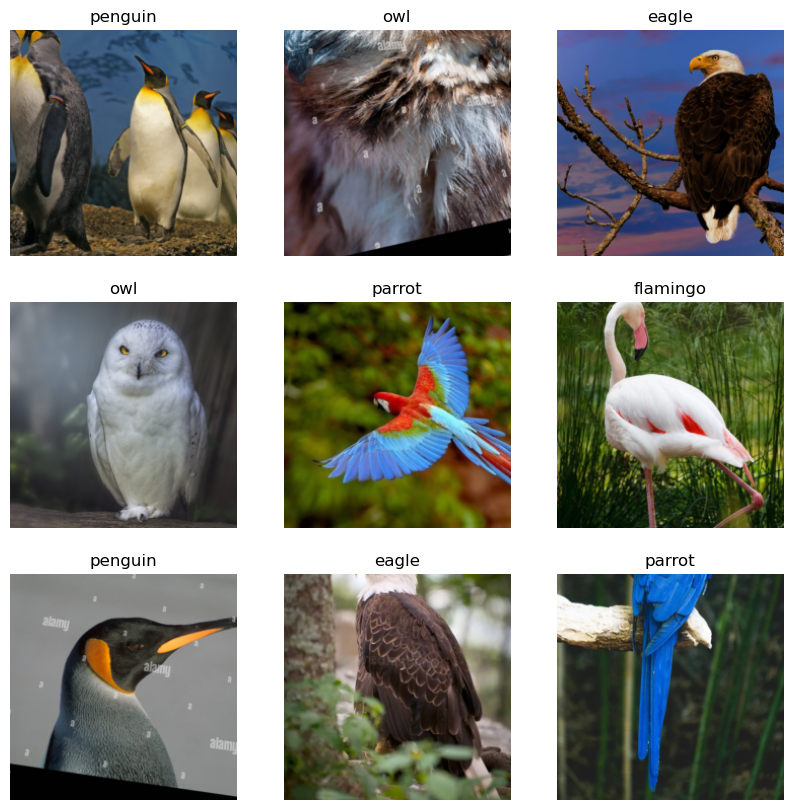

In [20]:
# Visualize a training batch with augmentations
dls.show_batch(max_n=9, figsize=(10, 10))

## Understanding Data Augmentation

Notice how the same image looks different each time? That's **data augmentation**.

| Augmentation | What It Does | Why It Helps |
|--------------|--------------|---------------|
| Random crop | Different parts of image | Position invariance |
| Horizontal flip | Mirror image | Left/right invariance |
| Rotation | Slight rotation | Angle invariance |
| Lighting | Brightness/contrast | Lighting invariance |
| Warp | Slight distortion | Shape robustness |

**Augmentation artificially increases your dataset size and prevents overfitting.**

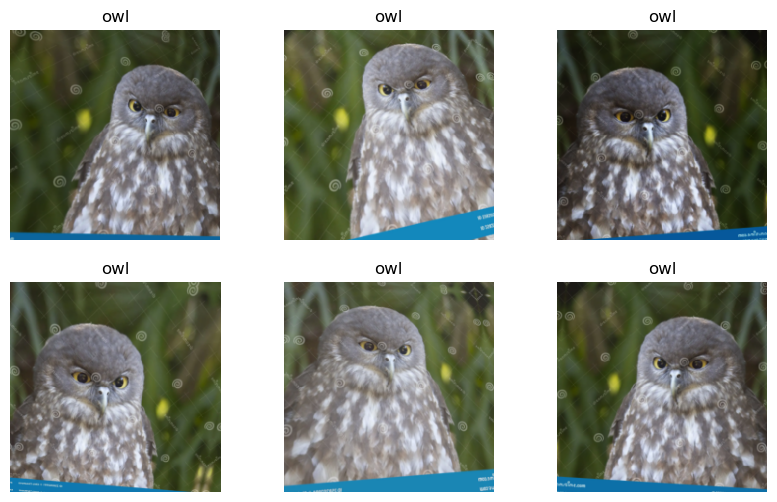

In [33]:
# Show same image with different augmentations
# This demonstrates what the model sees during training

dls.train.show_batch(max_n=6, unique=True, figsize=(10, 6))

---

## ✏️ Exercise 2: DataBlock Customization

What would you change in the DataBlock for these scenarios?

1. **You have more data (10,000 images)** - What batch size might work better? Why?

2. **Your images are already 224x224** - Do you still need `item_tfms=Resize(460)`?

3. **You're classifying faces for identity** - Should you use `RandomHorizontalFlip`? (Hint: is a flipped face still the same person?)

4. **You want a 90/10 train/val split** - How would you modify the splitter?

5. **Your classes are very imbalanced (1000 eagles, 50 owls)** - What problem might this cause?

---

### 💬 LLM Discussion Prompts

Use these prompts with an LLM to deepen your understanding:

> "Why does Fast.ai resize to 460px and then crop to 224px instead of resizing directly to 224px? Explain with an example."

> "I'm building a classifier for handwritten digits (0-9). Which data augmentations would help and which would hurt? Would rotating a 6 by 180 degrees still be a 6?"

> "What's the difference between item_tfms and batch_tfms? Why does resizing happen in item_tfms but augmentation in batch_tfms?"

---

# Part 5: Training the Model

## What Happens During Training?

At the highest level, training is an iterative refinement process:

```
┌─────────────────────────────────────────────────────────────────┐
│                     ONE TRAINING EPOCH                          │
├─────────────────────────────────────────────────────────────────┤
│                                                                  │
│   For each batch of 32 images:                                  │
│                                                                  │
│   1. FORWARD PASS                                               │
│      Images → Model → Predictions                               │
│      (What does the model think these are?)                     │
│                                                                  │
│   2. LOSS CALCULATION                                           │
│      Compare predictions to true labels                         │
│      (How wrong was the model?)                                 │
│                                                                  │
│   3. BACKWARD PASS                                              │
│      Calculate gradients via backpropagation                    │
│      (Which weights caused the errors?)                         │
│                                                                  │
│   4. WEIGHT UPDATE                                              │
│      Adjust weights using gradients × learning rate             │
│      (Fix the weights that caused errors)                       │
│                                                                  │
└─────────────────────────────────────────────────────────────────┘
```

With 720 images and batch size 32, each epoch processes ~23 batches.
Each batch performs all 4 steps, so weights are updated 23 times per epoch.

## The Fine-Tuning Strategy

Fine-tuning is NOT just training on new data. It's a carefully designed strategy that respects the knowledge already in the pretrained model.

Fast.ai's `fine_tune()` implements a two-phase approach:

### Phase 1: Freeze and Train Head (1 epoch)

The pretrained model ends with a "head" designed for ImageNet's 1000 classes. We replace it with a new head for our 5 bird classes, then train ONLY this new head while keeping everything else frozen.

**Why freeze?** The pretrained layers contain valuable learned features. Training them immediately with random gradients from our untrained head would destroy this knowledge.

### Phase 2: Unfreeze and Fine-Tune (remaining epochs)

After the head learns reasonable predictions, we unfreeze all layers and train the entire network. But not equally - we use **discriminative learning rates**.

```
┌─────────────────────────────────────────────────────────────────┐
│               DISCRIMINATIVE LEARNING RATES                     │
├─────────────────────────────────────────────────────────────────┤
│                                                                  │
│   Layer Group       Learning Rate    Why?                       │
│   ─────────────────────────────────────────────────────────────│
│   New Head          1e-2             New, needs big updates     │
│   Late layers       1e-3             Task-specific, adjust more │
│   Middle layers     1e-4             Semi-general features      │
│   Early layers      1e-5             Universal, change little   │
│                                                                  │
│   Visual representation:                                        │
│                                                                  │
│   [Early]  ─────────────►  [Late]  ─────────────►  [Head]       │
│    Edges       Textures       Parts       Objects     Classes   │
│                                                                  │
│      ▲            ▲            ▲            ▲           ▲       │
│    Tiny         Small       Medium       Larger     Largest     │
│   changes      changes      changes      changes     changes    │
│                                                                  │
└─────────────────────────────────────────────────────────────────┘
```

**Real example:** An edge detector learned on ImageNet works perfectly for birds too. A dog-vs-cat detector layer needs significant adjustment.

## Understanding the Freeze/Unfreeze Pattern

This pattern prevents "catastrophic forgetting" - when a neural network forgets previously learned knowledge while learning new tasks.

```
Strategy 1: Train All Layers Immediately (BAD)
──────────────────────────────────────────────
Epoch 0: Random head produces garbage gradients
         → Gradients flow backward through network
         → Good pretrained weights get corrupted
         → Model "forgets" how to see edges, textures
         → Must re-learn everything from scratch
         
Strategy 2: Freeze Then Unfreeze (GOOD)
──────────────────────────────────────────────
Epoch 0: Train head only
         → Head learns to produce reasonable outputs
         → Pretrained weights stay safe
Epoch 1+: Unfreeze with small learning rates
         → Now gradients are meaningful, not noise
         → Gentle adjustments refine features
         → Best of both worlds
```

## A Note on Batch Normalization

ResNet uses **batch normalization** layers that track running statistics of activations. During fine-tuning, there's a subtle issue: these statistics were computed on ImageNet, not birds.

Fast.ai handles this by:
1. Keeping batch norm layers frozen initially
2. Gradually unfreezing them
3. Using large enough batches for stable statistics

This is why batch size matters more in transfer learning than training from scratch.

In [37]:
# Create a learner with pre-trained ResNet18

learn = vision_learner(
    dls,           # Our data
    resnet34,      # Pre-trained architecture
    metrics=error_rate  # Track error rate during training
)

print("Learner created!")
print(f"\nModel: ResNet18 (pretrained on ImageNet)")
print(f"Output classes: {len(dls.vocab)}")

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /home/ua-tobias/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:01<00:00, 56.5MB/s]


Learner created!

Model: ResNet18 (pretrained on ImageNet)
Output classes: 5


SuggestedLRs(valley=0.0012022644514217973)

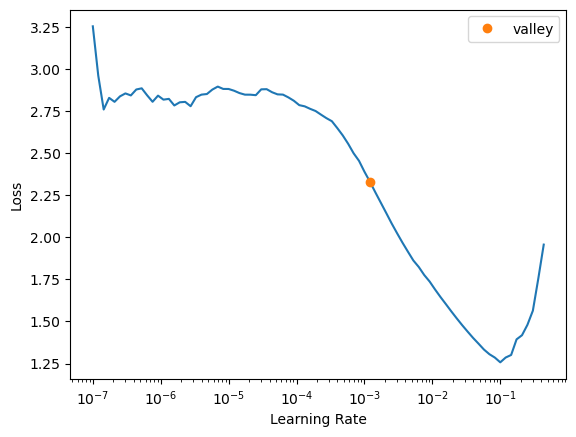

In [38]:
# Find optimal learning rate
# This plots loss vs learning rate to find the sweet spot

learn.lr_find()

### Reading the Learning Rate Finder

- **Too low**: Loss decreases very slowly
- **Just right**: Loss decreases rapidly (pick this!)
- **Too high**: Loss explodes or oscillates

**Rule of thumb:** Pick a learning rate where the loss is still decreasing rapidly, typically 1-2 orders of magnitude before the minimum.

In [39]:
# Fine-tune the model!
# This is where the magic happens

print("Starting fine-tuning...")
print("Epoch 0: Training only the new classification head (backbone frozen)")
print("Epochs 1-3: Training all layers with discriminative learning rates")
print("\n" + "=" * 60)

learn.fine_tune(4)  # 4 epochs total

Starting fine-tuning...
Epoch 0: Training only the new classification head (backbone frozen)
Epochs 1-3: Training all layers with discriminative learning rates



epoch,train_loss,valid_loss,error_rate,time
0,1.080353,0.032569,0.010638,00:04


epoch,train_loss,valid_loss,error_rate,time
0,0.090792,0.018960,0.010638,00:04
1,0.060720,0.008534,0.000000,00:04
2,0.049341,0.005915,0.005319,00:04
3,0.043985,0.008906,0.005319,00:04


---

## ✏️ Exercise 3: Training Experiments

Try different training configurations and compare results.

In [ ]:
# EXERCISE: Uncomment ONE experiment at a time, run, and compare results
# After each, reset with: learn = vision_learner(dls, resnet34, metrics=error_rate)

# Experiment 1: Very short training - will model converge?
# learn.fine_tune(1)

# Experiment 2: Higher learning rate (may be unstable)  
# learn.fine_tune(4, base_lr=1e-2)

# Experiment 3: Lower learning rate (slower but stable)
# learn.fine_tune(4, base_lr=1e-5)

# Record your results:
# | Experiment | Final Error Rate | Observations |
# |------------|------------------|--------------|
# | 1 epoch    |                  |              |
# | High LR    |                  |              |
# | Low LR     |                  |              |

---

# Part 6: Evaluating the Model

## Beyond Accuracy: Understanding Model Performance

A single accuracy number (e.g., "92% accurate") hides important details:
- Is the model equally good at all classes?
- When it fails, how does it fail?
- Are errors random or systematic?

### The Accuracy Trap

Consider this scenario:

```
Dataset: 1000 images
- 950 eagles (95%)
- 50 owls (5%)

Naive model: "Everything is an eagle"
- Gets 950/1000 = 95% accuracy!
- Completely useless for detecting owls
```

This is why we need multiple evaluation perspectives.

## Confusion Matrix Explained

A confusion matrix shows ALL predictions vs ALL true labels:

```
┌──────────────────────────────────────────────────────────────────┐
│                      CONFUSION MATRIX                            │
├──────────────────────────────────────────────────────────────────┤
│                                                                   │
│                     PREDICTED CLASS                               │
│              ┌────────┬────────┬────────┬────────┐               │
│              │ Eagle  │  Owl   │ Parrot │Penguin │               │
│         ┌────┼────────┼────────┼────────┼────────┤               │
│         │Eag │  23 ✓  │   2    │   0    │   0    │ ← Row = TRUE  │
│  TRUE   ├────┼────────┼────────┼────────┼────────┤               │
│  CLASS  │Owl │   1    │  21 ✓  │   2    │   1    │               │
│         ├────┼────────┼────────┼────────┼────────┤               │
│         │Par │   0    │   1    │  24 ✓  │   0    │               │
│         ├────┼────────┼────────┼────────┼────────┤               │
│         │Pen │   0    │   0    │   0    │  25 ✓  │               │
│         └────┴────────┴────────┴────────┴────────┘               │
│                                                                   │
│   Diagonal (✓) = Correct predictions                             │
│   Off-diagonal = Mistakes (row confused as column)               │
│                                                                   │
└──────────────────────────────────────────────────────────────────┘
```

**How to read it:** The cell at (Owl row, Parrot column) = 2 means:
"2 images that were actually owls got predicted as parrots"

### Per-Class Metrics from Confusion Matrix

From the matrix above, for the Owl class:
- **True Positives (TP)**: 21 (correctly identified as owl)
- **False Negatives (FN)**: 4 (owls misclassified as something else)
- **False Positives (FP)**: 3 (non-owls misclassified as owl)

**Precision** = TP / (TP + FP) = 21 / 24 = 87.5%
"Of images predicted as owl, what % actually are?"

**Recall** = TP / (TP + FN) = 21 / 25 = 84%
"Of actual owls, what % did we catch?"

## Top Losses: Your Debugging Tool

Top losses show images where the model was most wrong (high loss = confident and wrong).

```
┌─────────────────────────────────────────────────────────────────┐
│                   INTERPRETING TOP LOSSES                       │
├─────────────────────────────────────────────────────────────────┤
│                                                                  │
│   Scenario                       What to do                     │
│   ─────────────────────────────────────────────────────────────│
│   Image is mislabeled            Fix the label or remove image  │
│   (eagle in owl folder)                                         │
│                                                                  │
│   Image is truly ambiguous       Consider removing or keeping   │
│   (owl flying, looks like eagle) as training difficulty         │
│                                                                  │
│   Image is edge case             Collect more similar examples  │
│   (baby owl, unusual angle)      to train on                    │
│                                                                  │
│   Multiple classes in image      Crop or remove                 │
│   (parrot AND flamingo)                                         │
│                                                                  │
│   Clear image, model wrong       Model weakness - may need      │
│   (obvious parrot, said owl)     more training data             │
│                                                                  │
└─────────────────────────────────────────────────────────────────┘
```

## The Iterative Improvement Loop

Real ML work is cyclical:

```
    ┌─────────────┐
    │   Train     │
    └──────┬──────┘
           │
           ▼
    ┌─────────────┐
    │  Evaluate   │ ─── Look at confusion matrix, top losses
    └──────┬──────┘
           │
           ▼
    ┌─────────────┐
    │  Diagnose   │ ─── Why is model failing on these?
    └──────┬──────┘
           │
           ▼
    ┌─────────────┐
    │ Fix Data    │ ─── Remove bad images, add more examples
    └──────┬──────┘
           │
           └───────────────► Repeat
```

**In practice, data quality improvements often beat model changes.**

In [ ]:
# Create interpretation object
interp = ClassificationInterpretation.from_learner(learn)

print("Interpretation object created!")
print("This analyzes model predictions on the validation set.")

In [ ]:
# Confusion Matrix
# Rows = actual class, Columns = predicted class
# Diagonal = correct predictions

interp.plot_confusion_matrix(figsize=(8, 8))

### Reading the Confusion Matrix

- **Diagonal (top-left to bottom-right)**: Correct predictions
- **Off-diagonal**: Mistakes
- **Row = True class, Column = Predicted class**

Example: If cell (eagle, owl) = 3, the model predicted "owl" for 3 eagle images.

In [ ]:
# Top Losses - images the model was most wrong about
# These reveal:
# - Mislabeled training data
# - Ambiguous images
# - Edge cases

interp.plot_top_losses(9, figsize=(12, 12))

### Analyzing Top Losses

For each image, you see:
- **Prediction / Actual / Loss / Probability**

High loss can mean:
1. **Mislabeled data** - Image is in wrong folder
2. **Ambiguous image** - Even humans would struggle
3. **Unusual example** - Rare pose, lighting, etc.
4. **Model weakness** - Pattern the model missed

---

# Part 7: Making Predictions

## Inference vs Training Mode

When making predictions, the model behaves differently than during training:

```
┌─────────────────────────────────────────────────────────────────┐
│                 TRAINING vs INFERENCE MODE                      │
├─────────────────────────────────────────────────────────────────┤
│                                                                  │
│   Component          Training           Inference               │
│   ─────────────────────────────────────────────────────────────│
│   Dropout            Active (random)    Disabled                │
│   Batch Norm         Uses batch stats   Uses running stats      │
│   Gradients          Computed           Not computed            │
│   Augmentation       Applied            Not applied             │
│   Memory usage       High               Lower                   │
│                                                                  │
└─────────────────────────────────────────────────────────────────┘
```

Fast.ai's `learn.predict()` automatically handles this by calling `model.eval()`.

## Understanding Model Confidence

The model outputs **probabilities** for each class. But what do these really mean?

```
Prediction: Eagle (95% confident)

Does this mean:
  (a) The model is 95% sure this is an eagle?
  (b) 95% of similar images in training were eagles?
  (c) This image matches the "eagle pattern" 95% as well as perfect eagles?

Answer: None of the above, exactly. Neural network probabilities are 
often poorly calibrated - a 95% prediction might only be correct 85% 
of the time in practice.
```

### When to Trust Predictions

| Confidence Level | Interpretation |
|------------------|----------------|
| 95%+ | Model is very confident - usually reliable |
| 70-95% | Moderate confidence - worth checking |
| 50-70% | Low confidence - model is uncertain |
| <50% | Very uncertain - essentially guessing |

**Rule of thumb:** Set a confidence threshold below which you flag predictions for human review.

## Test-Time Augmentation (TTA)

For important predictions, you can improve accuracy using TTA:

```
┌─────────────────────────────────────────────────────────────────┐
│                  TEST-TIME AUGMENTATION                         │
├─────────────────────────────────────────────────────────────────┤
│                                                                  │
│   Original image                                                │
│        │                                                        │
│        ├── Original → Predict → [0.7, 0.2, 0.1]                │
│        ├── Flipped  → Predict → [0.8, 0.1, 0.1]                │
│        ├── Cropped1 → Predict → [0.6, 0.3, 0.1]                │
│        ├── Cropped2 → Predict → [0.9, 0.05, 0.05]              │
│        │                                                        │
│        └── Average all predictions                              │
│            Final: [0.75, 0.16, 0.09] → Class 0                 │
│                                                                  │
│   More robust than single prediction, but slower (4-5x)        │
│                                                                  │
└─────────────────────────────────────────────────────────────────┘
```

In Fast.ai: `learn.tta()` instead of `learn.predict()`

---

# Part 7: Making Predictions

Now let's use our trained model to classify new images.

In [ ]:
def predict_bird(image_path_or_url):
    """
    Predict the bird species in an image.
    
    Args:
        image_path_or_url: Path to local file or URL
    
    Returns:
        Predicted class and probabilities
    """
    # Load image
    if str(image_path_or_url).startswith('http'):
        img = PILImage.create(requests.get(image_path_or_url).content)
    else:
        img = PILImage.create(image_path_or_url)
    
    # Get prediction
    prediction, prediction_index, probabilities = learn.predict(img)
    
    # Display results
    print(f"Prediction: {prediction}")
    print(f"Confidence: {probabilities[prediction_index]:.1%}")
    print("\nAll probabilities:")
    
    for label, prob in zip(dls.vocab, probabilities):
        bar = '█' * int(prob * 30)
        marker = ' ◄' if label == prediction else ''
        print(f"  {label:10s}: {bar} {prob:.1%}{marker}")
    
    # Show image
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"Predicted: {prediction} ({probabilities[prediction_index]:.1%})")
    plt.axis('off')
    plt.show()
    
    return prediction, probabilities

---

# Part 8: Export and Deployment

## What Gets Saved?

When you call `learn.export()`, Fast.ai creates a pickle file containing:

```
┌─────────────────────────────────────────────────────────────────┐
│                   EXPORTED MODEL (.pkl)                         │
├─────────────────────────────────────────────────────────────────┤
│                                                                  │
│   1. MODEL ARCHITECTURE                                         │
│      - Network structure (ResNet18 with modified head)          │
│      - Layer configurations                                     │
│                                                                  │
│   2. TRAINED WEIGHTS                                            │
│      - All learned parameters (~11M for ResNet18)               │
│      - Batch norm running statistics                            │
│                                                                  │
│   3. DATA TRANSFORMS                                            │
│      - Resize parameters (224x224)                              │
│      - Normalization stats (ImageNet mean/std)                  │
│      - No augmentations (inference mode)                        │
│                                                                  │
│   4. CLASS VOCABULARY                                           │
│      - ['eagle', 'flamingo', 'owl', 'parrot', 'penguin']       │
│      - Mapping from predictions to class names                  │
│                                                                  │
└─────────────────────────────────────────────────────────────────┘
```

This means you can load and use the model without ANY of the training code - just `load_learner()` and `predict()`.

## Production Considerations

### Model Size Matters

| Architecture | Parameters | File Size | Inference Time |
|--------------|------------|-----------|----------------|
| ResNet18 | 11M | ~45 MB | ~5 ms |
| ResNet34 | 21M | ~85 MB | ~8 ms |
| ResNet50 | 25M | ~100 MB | ~12 ms |
| EfficientNet-B0 | 5M | ~20 MB | ~6 ms |

For mobile/edge deployment, smaller models are often better even if slightly less accurate.

### Optimization Techniques

```
┌─────────────────────────────────────────────────────────────────┐
│               MODEL OPTIMIZATION FOR PRODUCTION                 │
├─────────────────────────────────────────────────────────────────┤
│                                                                  │
│   Technique           Speedup    Accuracy Loss    Complexity    │
│   ─────────────────────────────────────────────────────────────│
│   TorchScript (JIT)   1.2-1.5x   None             Low           │
│   ONNX export         1.5-2x     None             Medium        │
│   Quantization (INT8) 2-4x       0-2%             Medium        │
│   Pruning             1.5-3x     0-5%             High          │
│   Knowledge Distill.  Varies     0-3%             High          │
│                                                                  │
└─────────────────────────────────────────────────────────────────┘
```

For most projects, the simple `.pkl` export is sufficient. Optimize only when you have clear performance requirements.

## Deployment Architecture

```
                    ┌────────────────────┐
                    │   User Uploads     │
                    │   Bird Image       │
                    └─────────┬──────────┘
                              │
                              ▼
┌─────────────────────────────────────────────────────────────────┐
│                        WEB SERVER                               │
│   ┌───────────────┐   ┌───────────────┐   ┌───────────────┐    │
│   │   API         │   │   Load        │   │   Return      │    │
│   │   Receives    │──►│   Model       │──►│   Prediction  │    │
│   │   Request     │   │   & Predict   │   │   as JSON     │    │
│   └───────────────┘   └───────────────┘   └───────────────┘    │
└─────────────────────────────────────────────────────────────────┘
                              │
                              ▼
                    ┌────────────────────┐
                    │ {"class": "eagle", │
                    │  "confidence": 0.95}│
                    └────────────────────┘
```

In [ ]:
# Test on a validation image
test_images = get_image_files(DATA_PATH/'eagle')[:3]

for img_path in test_images:
    predict_bird(img_path)
    print("\n" + "="*50 + "\n")

---

# Part 8: Export and Deployment

## Saving the Model

Fast.ai's `export()` saves everything needed for inference:
- Model architecture
- Trained weights
- Data transforms
- Class names

In [ ]:
# Export the model
MODEL_PATH = 'bird_classifier.pkl'
learn.export(MODEL_PATH)

print(f"Model exported to: {MODEL_PATH}")
print(f"File size: {Path(MODEL_PATH).stat().st_size / 1e6:.1f} MB")

In [ ]:
# Load and test the exported model
# This is exactly what your deployment code will do

inference_learner = load_learner(MODEL_PATH)

# Test prediction
test_img = get_image_files(DATA_PATH/'parrot')[0]
pred, _, probs = inference_learner.predict(test_img)

print(f"Loaded model prediction: {pred}")
print("\n✅ Model loads and predicts correctly!")

---

# Part 9: Summary and Next Steps

## Key Concepts Recap

| Concept | What You Learned |
|---------|------------------|
| **Transfer Learning** | Reuse pretrained weights, fine-tune for new task |
| **DataBlock API** | Declarative data pipeline: blocks, splitter, transforms |
| **Two-Stage Resize** | Resize to 460px → crop to 224px for better augmentation |
| **Data Augmentation** | Random transforms to artificially expand dataset |
| **Freeze/Unfreeze** | Train head first, then fine-tune all layers |
| **Discriminative LR** | Lower learning rates for earlier layers |
| **Confusion Matrix** | See per-class performance, find systematic errors |
| **Top Losses** | Debug model failures, find mislabeled data |
| **TTA** | Average multiple augmented predictions |
| **Export** | Save model + transforms + vocabulary for deployment |

## The Fast.ai Workflow Pattern

```python
# This pattern works for most vision tasks:

# 1. Create DataBlock (define how to load data)
dblock = DataBlock(blocks=(ImageBlock, CategoryBlock), ...)

# 2. Create DataLoaders (load the data)
dls = dblock.dataloaders(path)

# 3. Create Learner (connect model to data)
learn = vision_learner(dls, resnet18, metrics=error_rate)

# 4. Find learning rate
learn.lr_find()

# 5. Train
learn.fine_tune(epochs)

# 6. Evaluate
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()

# 7. Export
learn.export('model.pkl')
```

---

## 🏆 Challenges

### Challenge 1: More Classes (Difficulty: Easy)
Add 3 more bird species (hummingbird, toucan, peacock). Does accuracy change?

**Hints:**
- Update `BIRD_CLASSES` and `SEARCH_QUERIES`
- Re-download and clean data
- Compare confusion matrix with 5 classes vs 8 classes

---

### Challenge 2: Different Architecture (Difficulty: Easy)
Try `resnet34`, `resnet50`, or `efficientnet_b0`. Compare training time, memory usage, and accuracy.

**Hints:**
- `learn = vision_learner(dls, resnet34, metrics=error_rate)`
- Check GPU memory with `torch.cuda.memory_allocated()`
- Make a table comparing results

---

### Challenge 3: Test-Time Augmentation (Difficulty: Easy)
Use `learn.tta()` instead of `learn.validate()`. Does accuracy improve?

**Hints:**
- `preds, targs = learn.tta()`
- Compare with `learn.validate()`
- TTA is slower but more robust

---

### Challenge 4: Progressive Resizing (Difficulty: Medium)
Train first on 128x128 images, then 224x224. This is a technique used in competition-winning models.

**Hints:**
- Create two DataBlocks with different sizes
- `learn.fine_tune(2)` on small images
- Recreate dataloaders with larger size
- `learn.fine_tune(2)` again

---

### Challenge 5: Deploy to HuggingFace Spaces (Difficulty: Medium)
Actually deploy your model and share the link.

**Hints:**
- Create account at huggingface.co
- Create new Space (Gradio)
- Upload `bird_classifier.pkl` and `app.py`
- The Gradio code is already in this notebook

---

### Challenge 6: Custom Metric (Difficulty: Medium)
Add per-class accuracy as a custom metric during training.

**Hints:**
- Define a function that takes `inp, targ`
- Use `Metric` class from fastai
- Add to `metrics=[error_rate, your_metric]`

---

### Challenge 7: Handle Class Imbalance (Difficulty: Hard)
Artificially create imbalance (100 eagles, 20 owls). Fix it with class weights or oversampling.

**Hints:**
- `loss_func = CrossEntropyLossFlat(weight=class_weights)`
- Or use `WeightedRandomSampler` in PyTorch

---

### 💬 Final LLM Discussion Prompts

> "I've built my first image classifier. What should I learn next to become an ML engineer? Give me a roadmap."

> "How would this bird classifier need to change to handle millions of classes (like ImageNet)? What architectural changes are needed?"

> "Compare Fast.ai, PyTorch Lightning, and Keras. When would you choose each? What are the tradeoffs?"

---

*Created: 2025_12_25_2130 | Phase 2 Deep Learning Project*

In [ ]:
# CHALLENGE 1 STARTER CODE: Add more bird classes
# Uncomment and modify to add 3 new bird species

# NEW_CLASSES = ['hummingbird', 'toucan', 'peacock']
# 
# NEW_SEARCH_QUERIES = {
#     'hummingbird': ['hummingbird bird photography', 'hummingbird feeding flower'],
#     'toucan': ['toucan bird tropical rainforest', 'toucan portrait colorful beak'],
#     'peacock': ['peacock bird photography', 'peacock feathers display'],
# }
# 
# # Add to existing classes
# ALL_CLASSES = BIRD_CLASSES + NEW_CLASSES
# ALL_QUERIES = {**SEARCH_QUERIES, **NEW_SEARCH_QUERIES}
# 
# # Download new classes (run the download loop with ALL_CLASSES)
# # Then retrain and compare confusion matrices

## Deployment Options

| Platform | Difficulty | Cost | Use Case |
|----------|------------|------|----------|
| HuggingFace Spaces | Easy | Free | Demo, prototypes |
| Gradio local | Easy | Free | Development |
| FastAPI + Docker | Medium | Varies | Production API |
| AWS Lambda | Medium | Pay-per-use | Serverless |
| Replicate | Easy | Pay-per-use | Scalable API |

In [ ]:
# Gradio app for local testing
import gradio as gr

def classify_bird_gradio(image):
    """Gradio-compatible prediction function."""
    pred, _, probs = inference_learner.predict(image)
    return {label: float(prob) for label, prob in zip(inference_learner.dls.vocab, probs)}

# Create Gradio interface
demo = gr.Interface(
    fn=classify_bird_gradio,
    inputs=gr.Image(type='pil'),
    outputs=gr.Label(num_top_classes=5),
    title="Bird Classifier",
    description="Upload an image of a bird to classify it!"
)

# Launch (uncomment to run)
# demo.launch()

<div style="text-align: center; color: #888; font-size: 0.85em; margin-top: 40px; padding-top: 10px; border-top: 1px solid #ddd;">
© 2025 Utvecklarakademin UA Aktiebolag. All rights reserved.<br>
This material is proprietary and may not be reproduced, distributed, or shared without written permission.
</div>